In [198]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
import joblib


from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.stats import randint, uniform


from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

import eli5
from eli5.sklearn import PermutationImportance

pd.set_option('display.float_format',  '{:.3f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)

import warnings
warnings.filterwarnings("ignore")

In [172]:
df = pd.read_csv("Melbourne_housing_FULL.csv")
df_copy = df.copy()
df_copy.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.500,3067.000,2.000,1.000,1.000,126.000,NaN,NaN,Yarra City Council,-37.801,144.996,Northern Metropolitan,4019.000
1,Abbotsford,85 Turner St,2,h,1480000.000,S,Biggin,3/12/2016,2.500,3067.000,2.000,1.000,1.000,202.000,NaN,NaN,Yarra City Council,-37.800,144.998,Northern Metropolitan,4019.000
2,Abbotsford,25 Bloomburg St,2,h,1035000.000,S,Biggin,4/02/2016,2.500,3067.000,2.000,1.000,0.000,156.000,79.000,1900.000,Yarra City Council,-37.808,144.993,Northern Metropolitan,4019.000
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.500,3067.000,3.000,2.000,1.000,0.000,NaN,NaN,Yarra City Council,-37.811,145.012,Northern Metropolitan,4019.000
4,Abbotsford,5 Charles St,3,h,1465000.000,SP,Biggin,4/03/2017,2.500,3067.000,3.000,2.000,0.000,134.000,150.000,1900.000,Yarra City Council,-37.809,144.994,Northern Metropolitan,4019.000


## EDA

In [126]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  object 
 6   SellerG        34857 non-null  object 
 7   Date           34857 non-null  object 
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  object 
 17  Lattitude      26881 non-null  float64
 18  Longti

In [127]:
df_copy.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,34857.000,27247.000,34856.000,34856.000,26640.000,26631.000,26129.000,23047.000,13742.000,15551.000,26881.000,26881.000,34854.000
mean,3.031,1050173.345,11.185,3116.063,3.085,1.625,1.729,593.599,160.256,1965.290,-37.811,145.002,7572.888
std,0.970,641467.130,6.789,109.024,0.981,0.724,1.011,3398.842,401.267,37.328,0.090,0.120,4428.090
min,1.000,85000.000,0.000,3000.000,0.000,0.000,0.000,0.000,0.000,1196.000,-38.190,144.424,83.000
25%,2.000,635000.000,6.400,3051.000,2.000,1.000,1.000,224.000,102.000,1940.000,-37.863,144.934,4385.000
50%,3.000,870000.000,10.300,3103.000,3.000,2.000,2.000,521.000,136.000,1970.000,-37.808,145.008,6763.000
75%,4.000,1295000.000,14.000,3156.000,4.000,2.000,2.000,670.000,188.000,2000.000,-37.754,145.072,10412.000
max,16.000,11200000.000,48.100,3978.000,30.000,12.000,26.000,433014.000,44515.000,2106.000,-37.390,145.526,21650.000


In [128]:
df_copy.shape

(34857, 21)

In [129]:
df_copy.isnull().sum()

Suburb               0
Address              0
Rooms                0
Type                 0
Price             7610
Method               0
SellerG              0
Date                 0
Distance             1
Postcode             1
Bedroom2          8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21115
YearBuilt        19306
CouncilArea          3
Lattitude         7976
Longtitude        7976
Regionname           3
Propertycount        3
dtype: int64

In [130]:
df_copy.nunique()

Suburb             351
Address          34009
Rooms               12
Type                 3
Price             2871
Method               9
SellerG            388
Date                78
Distance           215
Postcode           211
Bedroom2            15
Bathroom            11
Car                 15
Landsize          1684
BuildingArea       740
YearBuilt          160
CouncilArea         33
Lattitude        13402
Longtitude       14524
Regionname           8
Propertycount      342
dtype: int64

In [131]:
df_copy.duplicated().sum()

np.int64(1)

### Insights of Initial Analysis:

#### The dataset consist of 34857 row and 21 variable.
#### 8 of the variables are categorical data type, and the rest (13) are numerical data type.
#### A little more than half of the variables (14) have one or more missing values.
#### There is only one duplicated data.

In [132]:
cat_cols = ['Suburb', 'Address', 'Type', 'Method', 
            'SellerG', 'Date', 'CouncilArea', 'Regionname']
num_cols = [col for col in df_copy.columns if col not in cat_cols]

## FEATURE ENGINEERING

### 1. Feature Extraction
##### 3 new features will be extracted from the "Date" variable. These new features are: Year, month and day the house was sold.
##### Another feature "Building_Age" will be extracted from "YearBuilt". 

In [133]:
df_copy['Date'] = pd.to_datetime(df_copy['Date'], format='%d/%m/%Y')

df_copy['Month_Sold'] = df_copy['Date'].dt.month
df_copy['Year_Sold'] = df_copy['Date'].dt.year
df_copy['Day_Sold'] = df_copy['Date'].dt.day_name()
df_copy['Date'] = df_copy['Date'].astype(str)

cat_cols.append('Day_Sold')

In [134]:
df_copy['Building_Age'] = datetime.now().year - df_copy['YearBuilt']
num_cols.append('Building_Age')

## 2.Correlated Variables

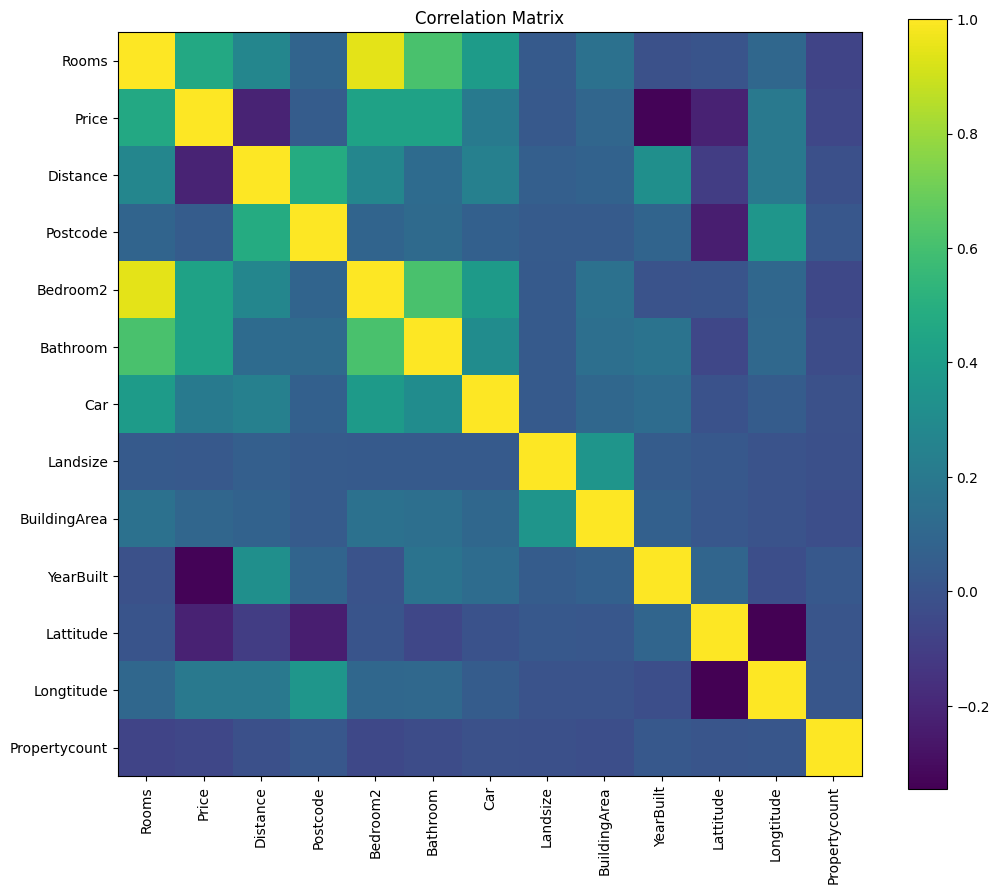

In [135]:
# Correlation Matrix

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12,10))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

The correlation between variables was examined with a threshold value of 0.65. One of the variables with a correlation above the threshold will be removed from the set.

In [136]:
def find_correlated_features(dataframe, threshold):
    s = dataframe.corr(numeric_only=True).unstack().sort_values(ascending=False)
    return s[s.abs().between(threshold, 1, inclusive='left')].drop_duplicates()

find_correlated_features(df_copy, 0.65)

Rooms      Bedroom2        0.947
YearBuilt  Building_Age   -1.000
dtype: float64

In [137]:
df_copy.drop(['Bedroom2'], inplace=True, axis=1)
num_cols.remove('Bedroom2')

### 3. Duplicated Rows

In [138]:
df_copy.loc[df_copy.duplicated(keep=False), :]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Month_Sold,Year_Sold,Day_Sold,Building_Age
15857,Nunawading,1/7 Lilian St,3,t,NaN,SP,Jellis,2017-06-17,15.400,3131.000,3.000,2.000,405.000,226.000,2000.000,Manningham City Council,-37.827,145.168,Eastern Metropolitan,4973.000,6,2017,Saturday,26.000
15858,Nunawading,1/7 Lilian St,3,t,NaN,SP,Jellis,2017-06-17,15.400,3131.000,3.000,2.000,405.000,226.000,2000.000,Manningham City Council,-37.827,145.168,Eastern Metropolitan,4973.000,6,2017,Saturday,26.000


In [139]:
df_copy.drop_duplicates(inplace=True, keep="first")

## 4. Missing Values

In [140]:
print(pd.concat([df_copy.isnull().sum(), df_copy.isnull().sum()/len(df_copy)*100],
                 keys=['Number of Missing Values', 'Ratio of Missing Values'],
                 axis=1))

               Number of Missing Values  Ratio of Missing Values
Suburb                                0                    0.000
Address                               0                    0.000
Rooms                                 0                    0.000
Type                                  0                    0.000
Price                              7609                   21.830
Method                                0                    0.000
SellerG                               0                    0.000
Date                                  0                    0.000
Distance                              1                    0.003
Postcode                              1                    0.003
Bathroom                           8226                   23.600
Car                                8728                   25.040
Landsize                          11810                   33.882
BuildingArea                      21115                   60.578
YearBuilt                

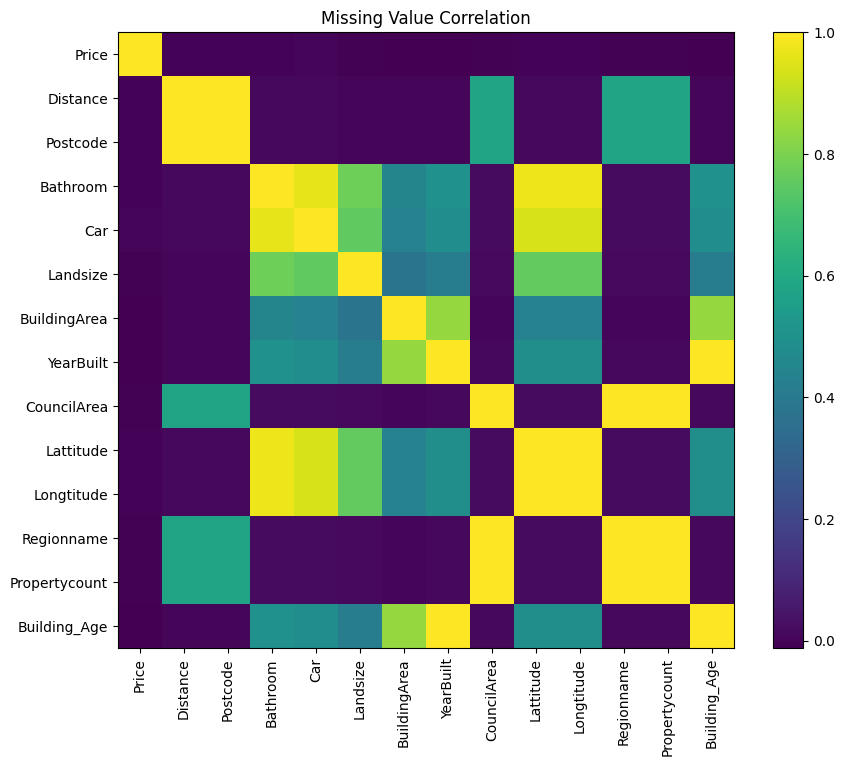

In [141]:
# Select only columns that have missing values
cols_with_na = df_copy.columns[df_copy.isnull().any()]

missing_df = df_copy[cols_with_na].isnull().astype(int)
missing_corr = missing_df.corr()

plt.figure(figsize=(10,8))
plt.imshow(missing_corr)
plt.colorbar()
plt.xticks(range(len(cols_with_na)), cols_with_na, rotation=90)
plt.yticks(range(len(cols_with_na)), cols_with_na)
plt.title("Missing Value Correlation")
plt.show()

The minimum values of Bathroom, Landsize, BuildingArea, and Bedroom2 are recorded as 0, which is unrealistic, so these values were converted to NA to represent missing data.


In [142]:
cols_with_missing_value_0 = ['Bathroom', 'Landsize', 'BuildingArea']
df_copy[cols_with_missing_value_0 ].eq(0).sum()

Bathroom          46
Landsize        2437
BuildingArea      76
dtype: int64

In [143]:
for col in cols_with_missing_value_0: 
    df_copy[col].replace({0: np.nan}, inplace=True)
    
df_copy[['Bathroom', 'Landsize', 'BuildingArea']].eq(0).sum()

Bathroom        0
Landsize        0
BuildingArea    0
dtype: int64

2. Changing the values of the "YearBuilt" variable I mentioned before. There are 9 houses built after the sale and 4 houses built before 1850.

In [144]:
df_copy.loc[(df_copy['YearBuilt'] > df_copy['Year_Sold']) | (df_copy['YearBuilt'] < 1850), 'YearBuilt'] = np.nan

The only missing data of these two variables is belong to 29483rd data. The 'Suburb' and 'Address' of this data are recorded as 'Fawkner Lot' and     '1/3 Brain St' respectively. That was the only data for the suburb 'Fawkner Lot'.

While reviewing the dataset, I came across two data for the suburb "Fawkner Lot, 1/3 Brain St". However, these data were recorded as "Fawkner" and    "3  Brain St". The only difference between these two data and data 29483 is "Date" (sales date).

As a result, I filled in one of the missing values observed in 'Postcode, Distinct, CouncilArea, Regionname, Propertycount' with the fully             registered  'Fawnker' data and changed Suburb variable "Fawnker Lot" 'to 'Fawnker'.

In [145]:
df_copy[df_copy["Postcode"].isnull()]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Month_Sold,Year_Sold,Day_Sold,Building_Age
29483,Fawkner Lot,1/3 Brian St,3,h,616000.000,SP,Brad,2018-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2018,Saturday,NaN


In [146]:
'Fawkner' in df_copy['Suburb'].unique()

True

In [147]:
df_copy.loc[(df_copy["Suburb"] == 'Fawkner') & (df_copy["Address"] == '3 Brian St')]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Month_Sold,Year_Sold,Day_Sold,Building_Age
11247,Fawkner,3 Brian St,3,h,625000.000,S,Brad,2016-12-10,12.400,3060.000,1.000,2.000,585.000,88.000,1960.000,Hume City Council,-37.695,144.968,Northern Metropolitan,5070.000,12,2016,Saturday,66.000
12756,Fawkner,3 Brian St,3,h,660000.000,S,Brad,2017-04-08,12.400,3060.000,1.000,2.000,585.000,88.000,1960.000,Hume City Council,-37.695,144.968,Northern Metropolitan,5070.000,4,2017,Saturday,66.000


In [148]:
for col, val in zip(df_copy.iloc[11247,:].index, df_copy.iloc[11247,:].values):
    if col in ['Date', 'Month', 'Year']:
        pass
    else:
        df_copy.loc[df_copy.index==29483, col] = val

In [149]:
'Fawkner Lot' in df_copy['Suburb'].unique()

False

All missing values (2) of these three variables belong to 18523rd and 26888th data. These data are respectively "Footscray, 2/16 Stafford St" and "Camberwell, 2/3 Kingsley St".

Consequently, I filled in the missing values of "CouncilArea, Regionname, Propertycount" with the values I found from the filtering "Suburb" and "Address".

For "Footscray, 2/16 Stafford St" these values are "Maribyrnong City Council, Western Metropolitan, 7570.0" respectively and for "Camberwell, 2/3 Kingsley St" the values are "Boroondara City Council, Southern Metropolitan, 8920.0" respectively.

In [150]:
pd.concat([df_copy[df_copy['Regionname'].isnull()],
           df_copy[df_copy['CouncilArea'].isnull()],
           df_copy[df_copy['Propertycount'].isnull()]]).drop_duplicates()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Month_Sold,Year_Sold,Day_Sold,Building_Age
18523,Footscray,2/16 Stafford St,2,u,710000.000,S,Jas,2017-07-15,5.100,3011.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,2017,Saturday,NaN
26888,Camberwell,2/3 Kingsley St,2,h,825000.000,VB,Jellis,2017-11-11,7.700,3124.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,2017,Saturday,NaN


In [151]:
footscray_sub_add_filter = (df_copy["Suburb"] == 'Footscray') & (df_copy["Address"] == '2/16 Stafford St')
camberwell_sub_add_filter = (df_copy["Suburb"] == 'Camberwell') & (df_copy["Address"] == '2/3 Kingsley St')

footscray_filter = df_copy["Suburb"] == 'Footscray'
camberwell_filter = df_copy["Suburb"] == 'Camberwell'

In [152]:
missing_cols = ['Regionname', 'CouncilArea', 'Propertycount']

for col in missing_cols:
    df_copy.loc[footscray_sub_add_filter, col] = df_copy.loc[footscray_filter][col].unique()[0]
    df_copy.loc[camberwell_sub_add_filter, col] = df_copy.loc[camberwell_filter][col].unique()[0]

In [153]:
df_copy.isnull().sum()

Suburb               0
Address              0
Rooms                0
Type                 0
Price             7609
Method               0
SellerG              0
Date                 0
Distance             0
Postcode             0
Bathroom          8271
Car               8727
Landsize         14246
BuildingArea     21190
YearBuilt        19318
CouncilArea          0
Lattitude         7975
Longtitude        7975
Regionname           0
Propertycount        0
Month_Sold           0
Year_Sold            0
Day_Sold             0
Building_Age     19305
dtype: int64

All records with missing values in the Price column were removed from the dataset to ensure accurate and reliable model training.

In [154]:
df_copy = df_copy.dropna(subset=['Price'])

## 5. Outlier Handling

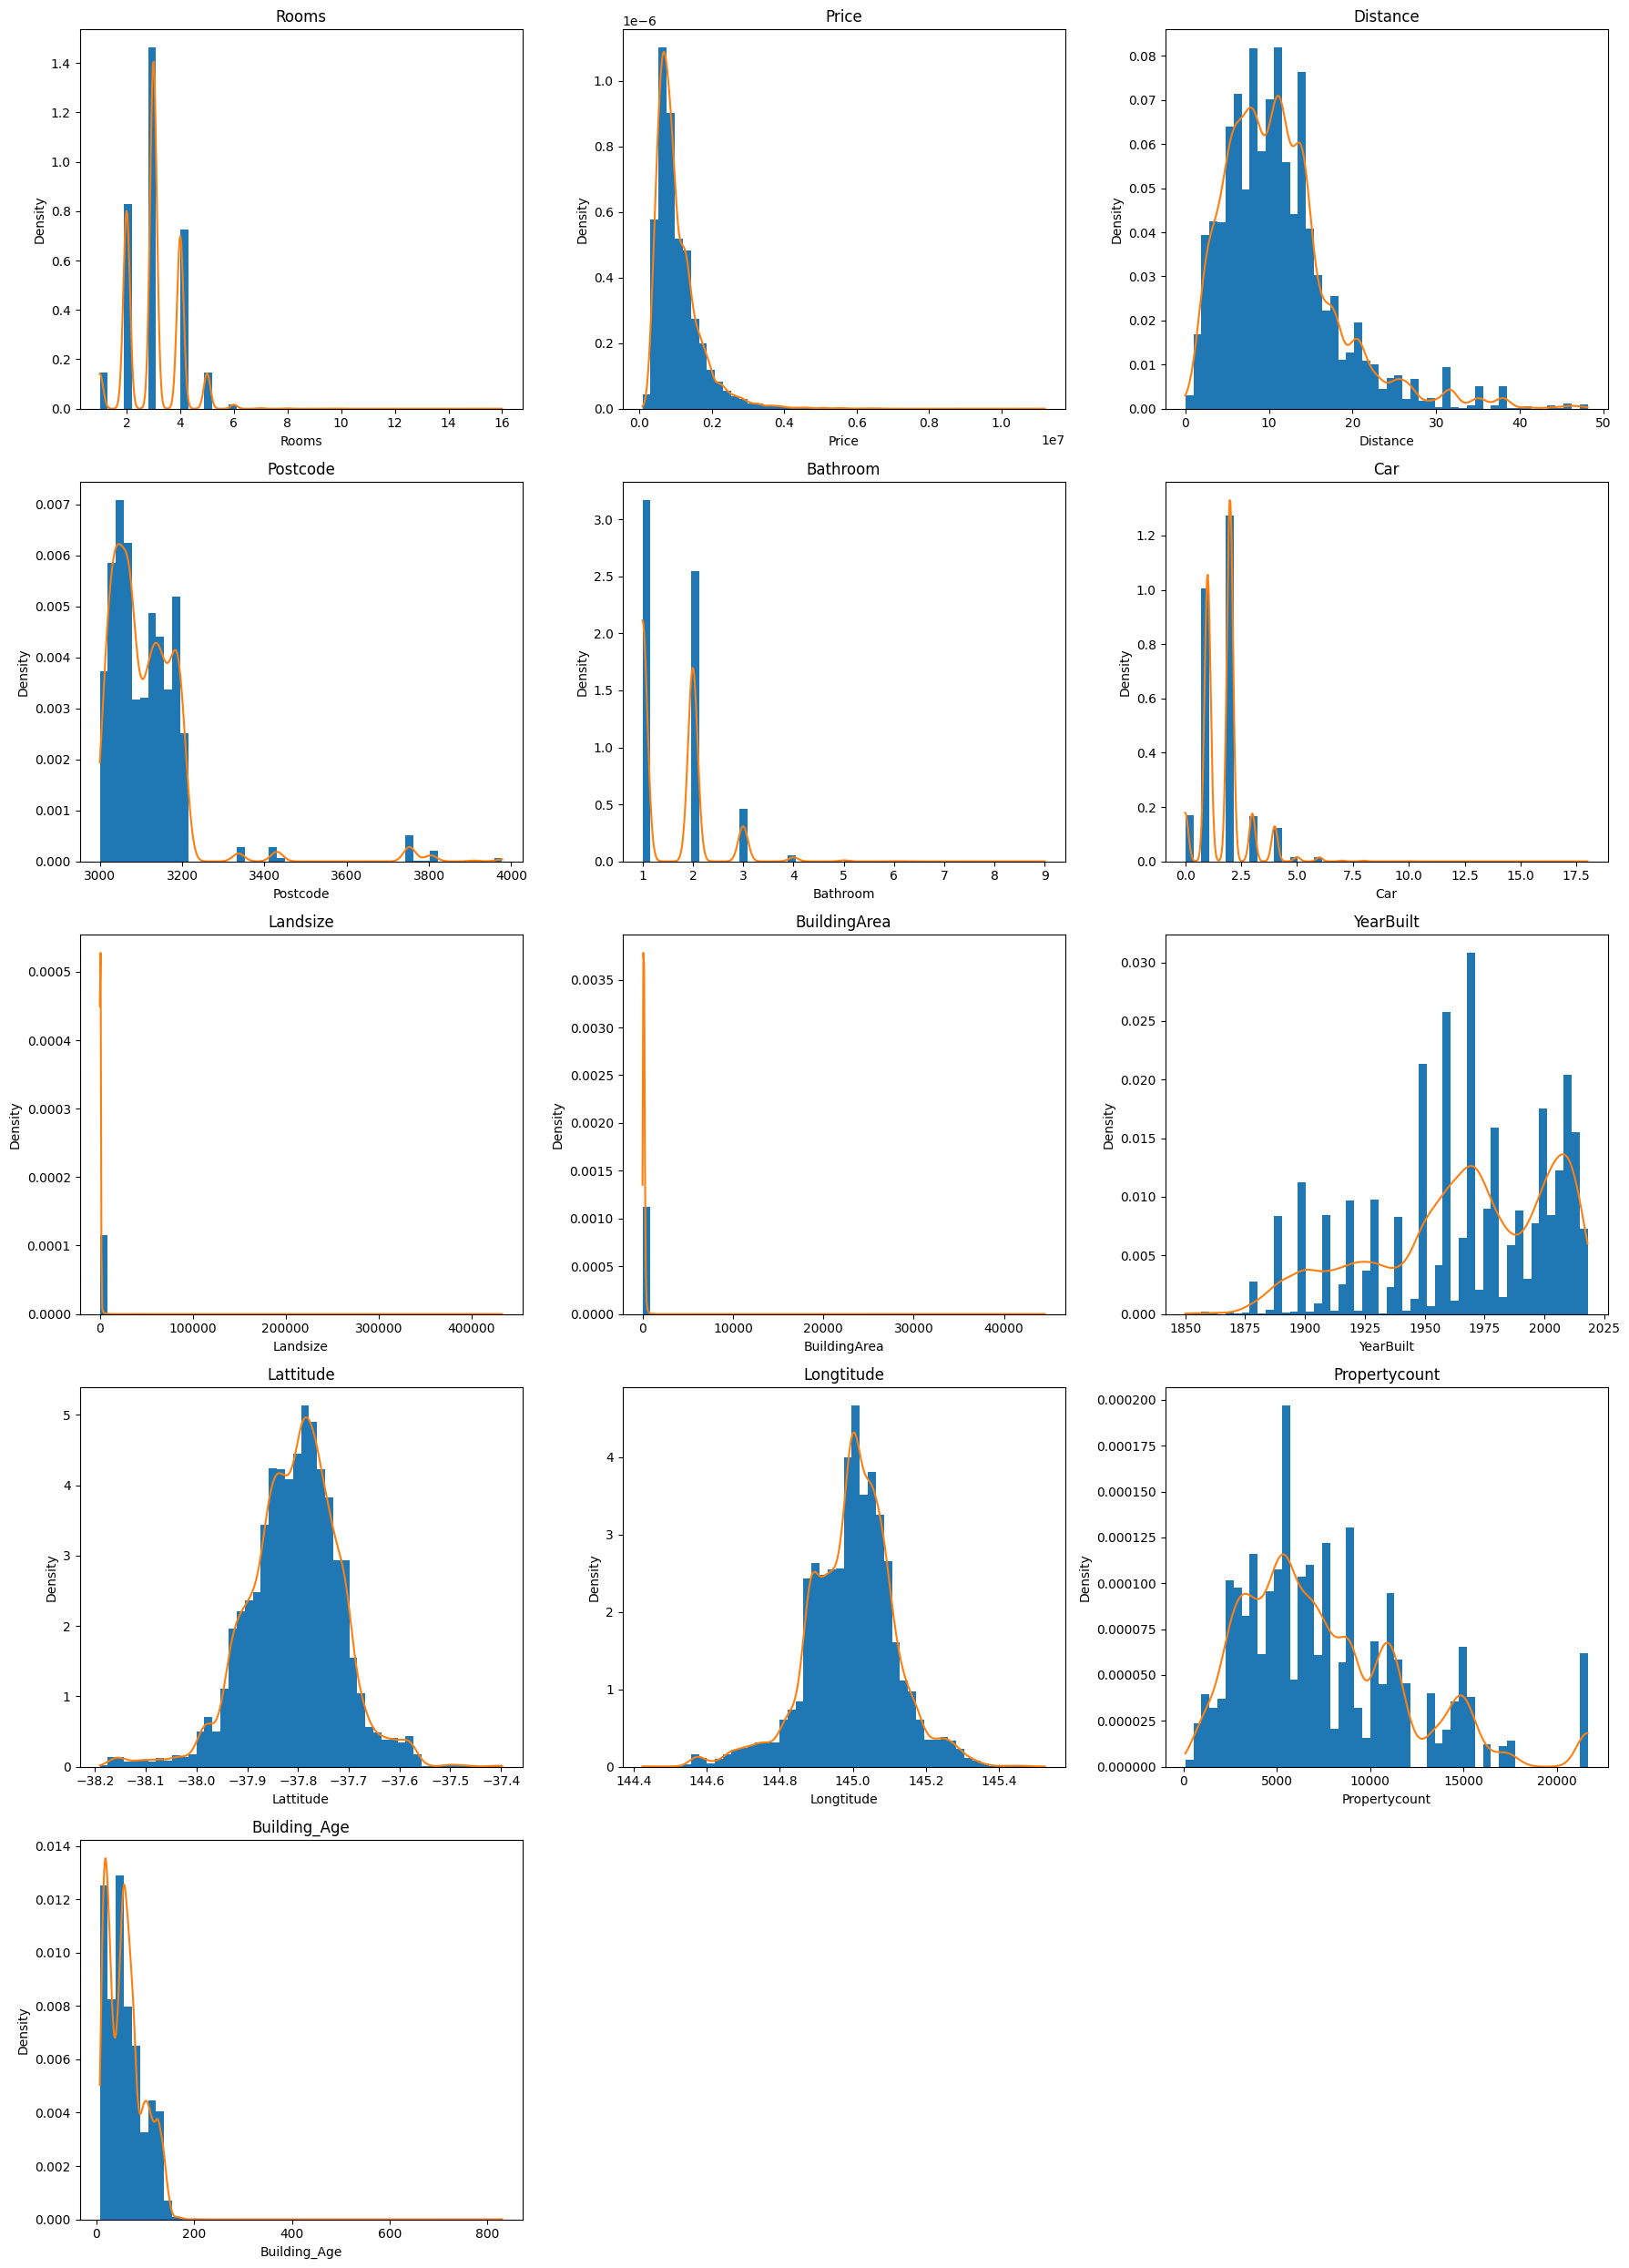

In [156]:
from scipy.stats import gaussian_kde
import math


n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    
    data = df_copy[col].dropna()
    
    # Histogram (normalized)
    axes[i].hist(data, bins=50, density=True)
    
    # Continuous KDE line
    if len(data) > 1:
        kde = gaussian_kde(data)
        x_vals = np.linspace(data.min(), data.max(), 500)
        axes[i].plot(x_vals, kde(x_vals))
    
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")

# Remove extra empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [157]:
def check_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[column] < lower) | 
                         (dataframe[column] > upper)]

    print(f"{column}: {len(outliers)} outliers")
    return outliers

In [158]:
num_cols = df_copy.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    check_outliers_iqr(df_copy, col)

Rooms: 23 outliers
Price: 1278 outliers
Distance: 1188 outliers
Postcode: 794 outliers
Bathroom: 238 outliers
Car: 1171 outliers
Landsize: 494 outliers
BuildingArea: 509 outliers
YearBuilt: 25 outliers
Lattitude: 530 outliers
Longtitude: 748 outliers
Propertycount: 727 outliers
Building_Age: 28 outliers


In [159]:
import pandas as pd
import numpy as np

# Select numeric columns
num_cols = df_copy.select_dtypes(include=['int64','float64']).columns

# Calculate skewness
skew_values = df_copy[num_cols].skew().sort_values(ascending=False)

# Define threshold
highly_skewed = skew_values[abs(skew_values) > 1]


print("Highly Skewed Columns (|skew| > 1):")
print(highly_skewed)

print("\nModerately Skewed Columns (0.5 < |skew| <= 1):")
print(skew_values[(abs(skew_values) > 0.5) & (abs(skew_values) <= 1)])

Highly Skewed Columns (|skew| > 1):
BuildingArea    90.827
Landsize        85.758
Postcode         3.982
Price            2.589
Car              1.639
Distance         1.479
Building_Age     1.316
Bathroom         1.309
Propertycount    1.016
dtype: float64

Moderately Skewed Columns (0.5 < |skew| <= 1):
Rooms        0.511
YearBuilt   -0.585
dtype: float64


In [160]:
log_cols = ['Price', 'Landsize', 'BuildingArea', 'Propertycount', 'Distance']

for col in log_cols:
    if col in df_copy.columns:
        df_copy[col] = np.log1p(df_copy[col])

In [161]:
cap_cols = ['Car', 'Bathroom']

def cap_iqr(df_copy, col):
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_copy[col] = np.clip(df_copy[col], lower, upper)

for col in cap_cols:
    if col in df_copy.columns:
        cap_iqr(df_copy, col)

In [162]:
num_cols = df_copy.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    check_outliers_iqr(df_copy, col)

Rooms: 23 outliers
Price: 214 outliers
Distance: 229 outliers
Postcode: 794 outliers
Bathroom: 0 outliers
Car: 0 outliers
Landsize: 462 outliers
BuildingArea: 339 outliers
YearBuilt: 25 outliers
Lattitude: 530 outliers
Longtitude: 748 outliers
Propertycount: 571 outliers
Building_Age: 28 outliers


In [163]:
cols_to_drop = ['Address', 'Date', 'YearBuilt']

df_copy.drop(columns=cols_to_drop, inplace=True)

cat_cols = [col for col in cat_cols if col not in cols_to_drop]
num_cols = [col for col in num_cols if col not in cols_to_drop]

In [164]:
X = df_copy.drop('Price', axis=1)
y = df_copy['Price']


In [165]:
# Train-test Splitting

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [186]:
from sklearn.pipeline import Pipeline


num_cols_ = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols_ = X_train.select_dtypes(include=['object']).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols_),
    ('cat', categorical_pipeline, cat_cols_)
])

## Model Building

In [189]:
models = {'Lasso': {'model': Lasso()},
          'LinearRegression': {'model': LinearRegression()},
          'Ridge': {'model': Ridge()},
          'ElasticNet': {'model': ElasticNet()},
          'KNeighborsRegressor': {'model': KNeighborsRegressor()},
          'RandomForestRegressor': {'model': RandomForestRegressor()},
          'GradientBoostingRegressor': {'model': GradientBoostingRegressor()},
          'AdaBoostRegressor': {'model': AdaBoostRegressor(n_estimators = 5, 
                                                           learning_rate = 1.2, 
                                                           loss = 'exponential', 
                                                           random_state = 2)},
          'DecisionTreeRegressor': {'model': DecisionTreeRegressor(max_depth = 9, 
                                                                   min_samples_split = 4, 
                                                                   random_state = 1)},
          'XGB': {'model': XGBRegressor(random_state=17, eval_metric='rmse')},
          'LightGBM': {'model': LGBMRegressor(random_state=17, verbose=-1)},
          'CatBoost': {'model': CatBoostRegressor(verbose=False)}}

df_scores = pd.DataFrame(columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2'])

for name, regressor in models.items():

    print("Running:", name)

    # Wrap inside pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", regressor['model'])
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_train_pred = pipeline.predict(X_train)

    # TEST METRICS
    mae_test = metrics.mean_absolute_error(y_test, y_pred)
    mse_test = metrics.mean_squared_error(y_test, y_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = metrics.r2_score(y_test, y_pred)

    # TRAIN METRICS
    mae_train = metrics.mean_absolute_error(y_train, y_train_pred)
    mse_train = metrics.mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = metrics.r2_score(y_train, y_train_pred)

    print('\n'.join([f'MAE  TEST:   {mae_test}',
                     f'MSE  TEST:   {mse_test}',
                     f'RMSE TEST:   {rmse_test}',
                     f'R2   TEST:   {r2_test}\n']))
    
    print('\n'.join([f'MAE  TRAIN:  {mae_train}',
                     f'MSE  TRAIN:  {mse_train}',
                     f'RMSE TRAIN:  {rmse_train}',
                     f'R2   TRAIN:  {r2_train}\n']))
    
    print("*************************\n")

    df_scores = df_scores._append({"Model": name,
                                   "MAE": mae_test,
                                   "MSE": mse_test,
                                   "RMSE": rmse_test,
                                   "R2": r2_test},
                                 ignore_index=True)


Running: Lasso
MAE  TEST:   0.41137818006378307
MSE  TEST:   0.26459829786471173
RMSE TEST:   0.5143911914727076
R2   TEST:   -1.9216783256448267e-05

MAE  TRAIN:  0.4138911878618092
MSE  TRAIN:  0.26790939873190694
RMSE TRAIN:  0.5175996510160212
R2   TRAIN:  0.0

*************************

Running: LinearRegression
MAE  TEST:   0.17837127848635403
MSE  TEST:   0.05618705389644213
RMSE TEST:   0.2370380853290081
R2   TEST:   0.7876474108703168

MAE  TRAIN:  0.17353139912118964
MSE  TRAIN:  0.053279292559890966
RMSE TRAIN:  0.2308230763158029
R2   TRAIN:  0.8011294384889917

*************************

Running: Ridge
MAE  TEST:   0.17801405749307475
MSE  TEST:   0.055978989684761206
RMSE TEST:   0.23659879476607906
R2   TEST:   0.7884337659288522

MAE  TRAIN:  0.17399026448428484
MSE  TRAIN:  0.05339605939432122
RMSE TRAIN:  0.23107587367425708
R2   TRAIN:  0.8006935940020757

*************************

Running: ElasticNet
MAE  TEST:   0.41137818006378307
MSE  TEST:   0.2645982978647117

In [193]:
df_scores = df_scores.sort_values("RMSE").reset_index(drop=True)
print(df_scores)

                        Model   MAE   MSE  RMSE     R2
0                    CatBoost 0.140 0.036 0.190  0.863
1                    LightGBM 0.146 0.039 0.198  0.853
2                         XGB 0.146 0.039 0.198  0.852
3       RandomForestRegressor 0.147 0.042 0.205  0.842
4   GradientBoostingRegressor 0.168 0.050 0.225  0.809
5         KNeighborsRegressor 0.174 0.055 0.235  0.791
6                       Ridge 0.178 0.056 0.237  0.788
7            LinearRegression 0.178 0.056 0.237  0.788
8       DecisionTreeRegressor 0.190 0.064 0.253  0.759
9           AdaBoostRegressor 0.247 0.101 0.318  0.618
10                      Lasso 0.411 0.265 0.514 -0.000
11                 ElasticNet 0.411 0.265 0.514 -0.000


## Compare Model

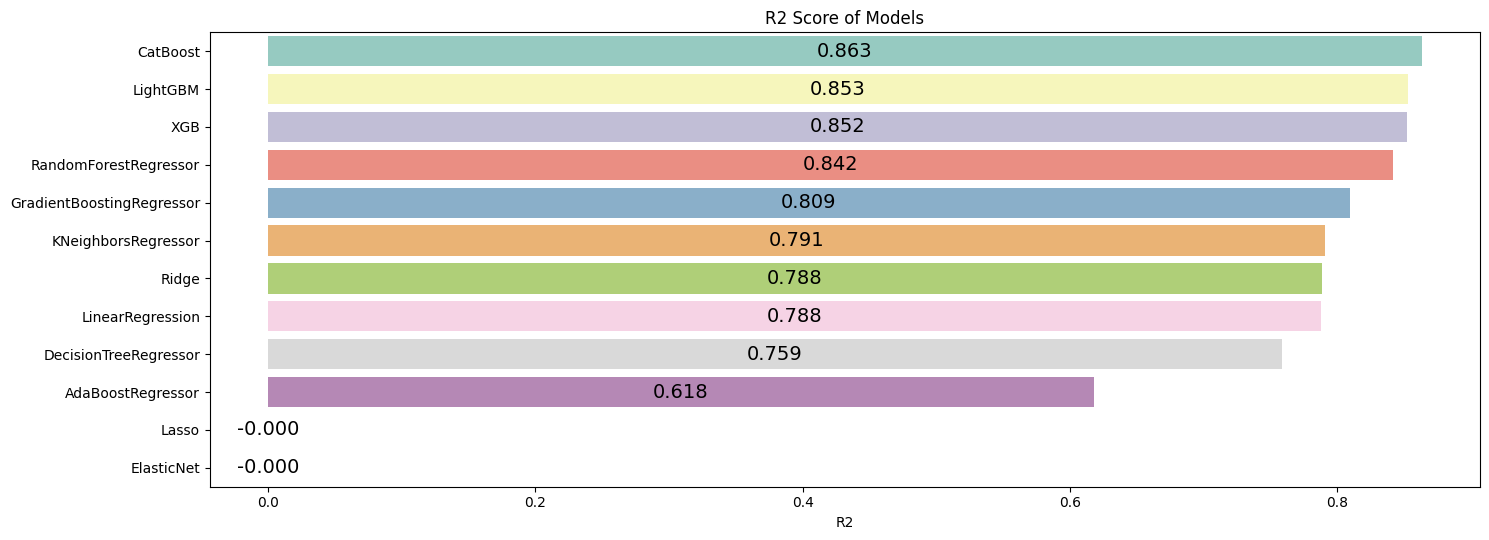

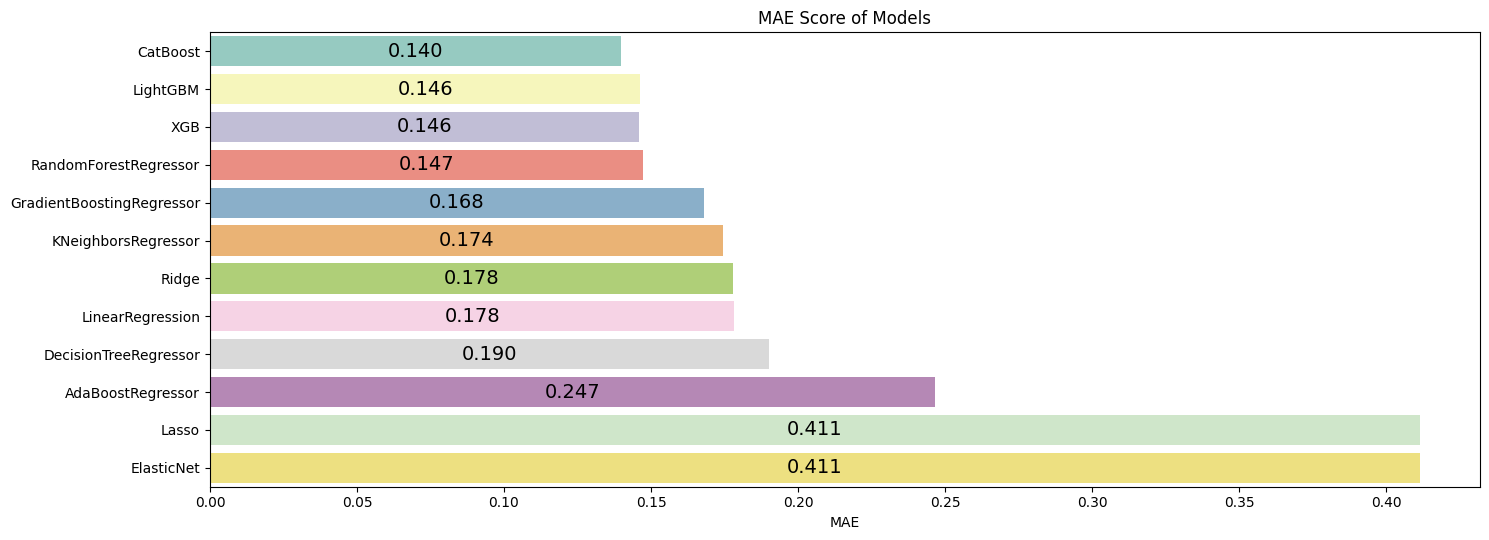

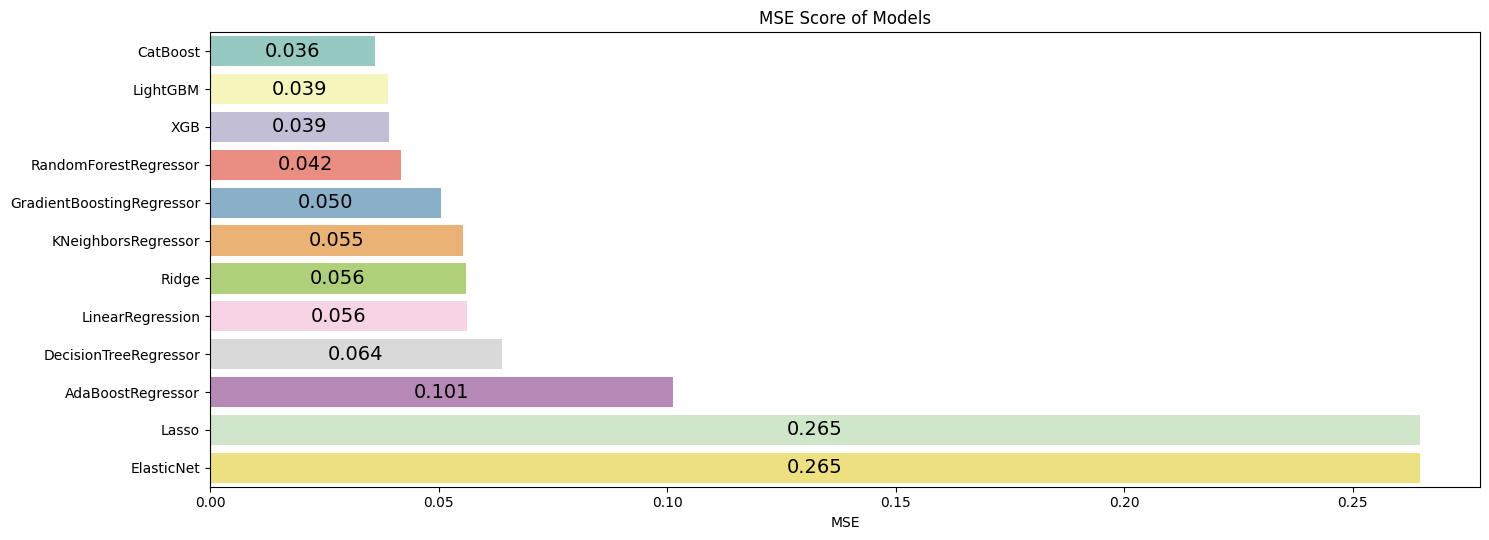

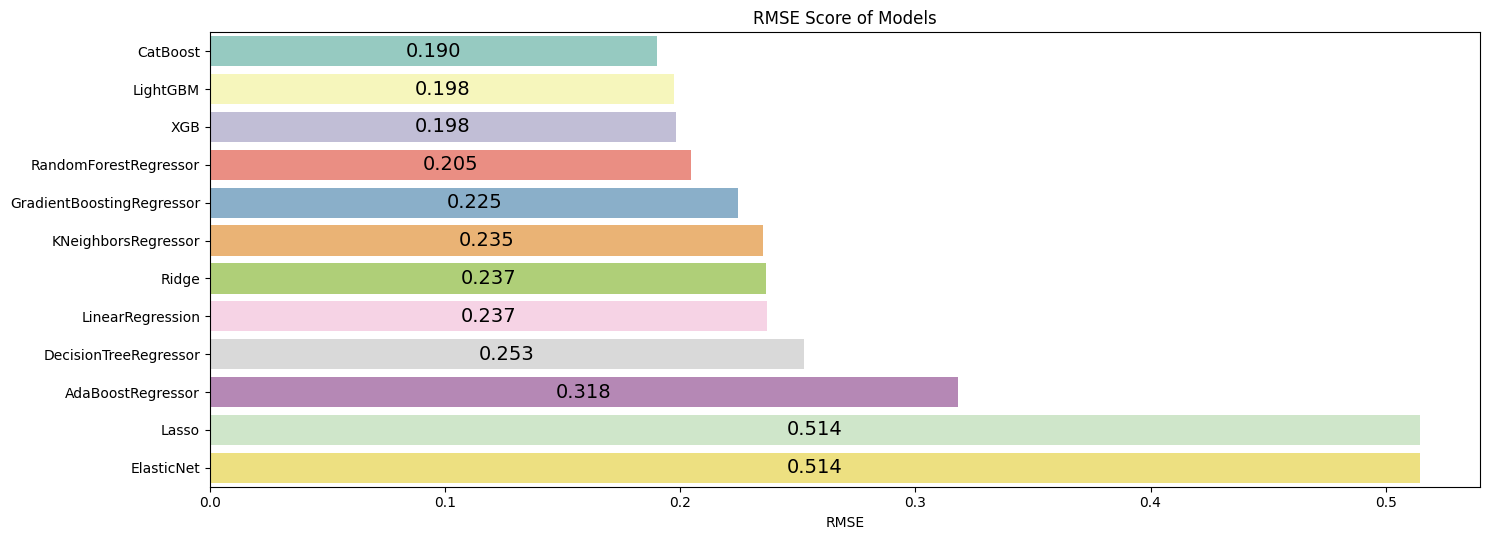

In [194]:
for col in df_scores[['R2', 'MAE', 'MSE', 'RMSE']]:
    plt.figure(figsize=(15, 5.5))
    ax = sns.barplot(data=df_scores, x=col, y='Model', palette='Set3');
    
    for container in ax.containers:
        ax.bar_label(container,  fmt='{:1.3f}', 
                     fontsize=14,  label_type='center')
    ax.set(ylabel='')
    plt.title(f'{col} Score of Models')
    plt.tight_layout()

In [196]:
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

df_scores = pd.DataFrame(columns=['Model','MAE','MSE','RMSE','R2'])

scoring = ['r2','neg_mean_absolute_error','neg_mean_squared_error','neg_root_mean_squared_error']

for name, regressor in models.items():

    print("Running:", name)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", regressor['model'])
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    mae = -scores['test_neg_mean_absolute_error'].mean()
    mse = -scores['test_neg_mean_squared_error'].mean()
    rmse = -scores['test_neg_root_mean_squared_error'].mean()
    r2 = scores['test_r2'].mean()

    print('\n'.join([f'MAE  CV:   {mae}',
                     f'MSE  CV:   {mse}',
                     f'RMSE CV:   {rmse}',
                     f'R2   CV:   {r2}\n']))

    print("*************************\n")

    df_scores = pd.concat([
        df_scores,
        pd.DataFrame([{
            "Model": name,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2
        }])
    ], ignore_index=True)

df_scores = df_scores.sort_values("RMSE").reset_index(drop=True)

print(df_scores)

Running: Lasso
MAE  CV:   0.4139036082649393
MSE  CV:   0.2679214724898924
RMSE CV:   0.5175677043939262
R2   CV:   -0.00011930259726171677

*************************

Running: LinearRegression
MAE  CV:   0.18001842299435528
MSE  CV:   0.05702964035241311
RMSE CV:   0.2388048763095282
R2   CV:   0.7869179904687182

*************************

Running: Ridge
MAE  CV:   0.17930678670272723
MSE  CV:   0.056546600819938876
RMSE CV:   0.237792027493197
R2   CV:   0.7887336593144072

*************************

Running: ElasticNet
MAE  CV:   0.4139036082649393
MSE  CV:   0.2679214724898924
RMSE CV:   0.5175677043939262
R2   CV:   -0.00011930259726171677

*************************

Running: KNeighborsRegressor
MAE  CV:   0.17684367883120977
MSE  CV:   0.056973557036661945
RMSE CV:   0.23867823315498668
R2   CV:   0.7872898814567204

*************************

Running: RandomForestRegressor
MAE  CV:   0.14893494286690037
MSE  CV:   0.042799113715695204
RMSE CV:   0.20687675631266073
R2   CV:   0

## HyperparameterTuning using GridSearchCV

In [197]:
LGBM_params = {
    'model__n_estimators': [100, 300, 500],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [5, 7, 9]
}

XGB_Regressor_params = {
    'model__n_estimators': [100, 300, 500],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [5, 7, 9]
}

CatBoost_params = {
    'model__iterations': [100, 500, 1000],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__depth': [5, 7, 9]
}

Random_Forest_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 4, 5, None]
}


models = [
    ("LightGBM", LGBMRegressor(random_state=17, verbose=-1), LGBM_params),
    ("XGB", XGBRegressor(random_state=17, eval_metric='rmse'), XGB_Regressor_params),
    ("CatBoost", CatBoostRegressor(verbose=False), CatBoost_params),
    ("RandomForestRegressor", RandomForestRegressor(random_state=42), Random_Forest_params)
]


from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np

best_models = {}
tuning_results = []

for name, model, params in models:

    print("Tuning:", name)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid = GridSearchCV(
        pipeline,
        params,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    best_rmse = -grid.best_score_

    tuning_results.append({
        "Model": name,
        "Best_RMSE": best_rmse,
        "Best_Params": grid.best_params_
    })

    print("Best RMSE:", best_rmse)
    print("Best Params:", grid.best_params_)
    print("***************************\n")

tuning_results_df = pd.DataFrame(tuning_results).sort_values("Best_RMSE")

print(tuning_results_df)

Tuning: LightGBM
Best RMSE: 0.1910634283557239
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 9, 'model__n_estimators': 500}
***************************

Tuning: XGB
Best RMSE: 0.19463952974311066
Best Params: {'model__learning_rate': 0.2, 'model__max_depth': 5, 'model__n_estimators': 500}
***************************

Tuning: CatBoost
Best RMSE: 0.1891516697827455
Best Params: {'model__depth': 9, 'model__iterations': 1000, 'model__learning_rate': 0.1}
***************************

Tuning: RandomForestRegressor
Best RMSE: 0.20618098076874328
Best Params: {'model__max_depth': None, 'model__n_estimators': 300}
***************************

                   Model  Best_RMSE                                        Best_Params
2               CatBoost      0.189  {'model__depth': 9, 'model__iterations': 1000,...
0               LightGBM      0.191  {'model__learning_rate': 0.1, 'model__max_dept...
1                    XGB      0.195  {'model__learning_rate': 0.2, 'model__max_d

## HyperparameterTuning using RandomizedSearchCV

In [199]:
LGBM_params = {
    'model__n_estimators': randint(100, 800),
    'model__learning_rate': uniform(0.01, 0.2),
    'model__max_depth': randint(3, 12)
}

XGB_params = {
    'model__n_estimators': randint(100, 800),
    'model__learning_rate': uniform(0.01, 0.2),
    'model__max_depth': randint(3, 12)
}

CatBoost_params = {
    'model__iterations': randint(200, 1000),
    'model__learning_rate': uniform(0.01, 0.2),
    'model__depth': randint(4, 10)
}

RF_params = {
    'model__n_estimators': randint(100, 600),
    'model__max_depth': randint(3, 15)
}

models = [
    ("LightGBM", LGBMRegressor(random_state=17, verbose=-1), LGBM_params),
    ("XGB", XGBRegressor(random_state=17, eval_metric='rmse'), XGB_params),
    ("CatBoost", CatBoostRegressor(verbose=False), CatBoost_params),
    ("RandomForest", RandomForestRegressor(random_state=42), RF_params)
]



results = []
best_models = {}

for name, model, params in models:

    print("Tuning:", name)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    random_search = RandomizedSearchCV(
        pipeline,
        param_distributions=params,
        n_iter=30,              # number of random combinations
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        random_state=42
    )

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    best_models[name] = best_model

    scores = cross_validate(
        best_model,
        X_train,
        y_train,
        cv=5,
        scoring=['r2','neg_mean_absolute_error','neg_root_mean_squared_error'],
        n_jobs=-1
    )

    rmse = -scores['test_neg_root_mean_squared_error'].mean()
    mae = -scores['test_neg_mean_absolute_error'].mean()
    r2 = scores['test_r2'].mean()

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Best_Params": random_search.best_params_
    })

    print("Best Params:", random_search.best_params_)
    print("RMSE:", rmse)
    print("*************************\n")

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

print(results_df)

Tuning: LightGBM
Best Params: {'model__learning_rate': np.float64(0.07234221521788219), 'model__max_depth': 8, 'model__n_estimators': 665}
RMSE: 0.1905089504724949
*************************

Tuning: XGB
Best Params: {'model__learning_rate': np.float64(0.07234221521788219), 'model__max_depth': 8, 'model__n_estimators': 665}
RMSE: 0.19482731670828007
*************************

Tuning: CatBoost
Best Params: {'model__depth': 9, 'model__iterations': 926, 'model__learning_rate': np.float64(0.11416685200516473)}
RMSE: 0.18924074355546294
*************************

Tuning: RandomForest
Best Params: {'model__max_depth': 14, 'model__n_estimators': 444}
RMSE: 0.20958928030482976
*************************

          Model  RMSE   MAE    R2                                        Best_Params
0      CatBoost 0.189 0.137 0.866  {'model__depth': 9, 'model__iterations': 926, ...
1      LightGBM 0.191 0.138 0.864  {'model__learning_rate': 0.07234221521788219, ...
2           XGB 0.195 0.141 0.858  {'mode

In [206]:
best_model = best_models["CatBoost"]
best_model.fit(X_train, y_train)

model = best_model.named_steps["model"]
importances = model.feature_importances_

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# remove prefixes
fi_df["Feature"] = fi_df["Feature"].str.replace("num__", "", regex=False)
fi_df["Feature"] = fi_df["Feature"].str.replace("cat__", "", regex=False)

# collapse only one-hot encoded categorical columns
def map_feature(name):
    for col in cat_cols:
        if name.startswith(col + "_"):
            return col
    return name

fi_df["Feature"] = fi_df["Feature"].apply(map_feature)

# aggregate
fi_df = fi_df.groupby("Feature", as_index=False)["Importance"].sum()

# sort
fi_df = fi_df.sort_values("Importance", ascending=False)

print(fi_df)

          Feature  Importance
13     Regionname      19.620
6        Distance      19.293
17           Type      14.739
14          Rooms      12.287
11       Postcode       4.772
7        Landsize       4.396
8       Lattitude       4.056
9      Longtitude       3.075
1    BuildingArea       2.583
16         Suburb       2.511
4     CouncilArea       2.479
0        Bathroom       2.455
15        SellerG       1.991
12  Propertycount       1.556
2    Building_Age       1.398
10         Method       1.375
3             Car       1.194
5        Day_Sold       0.220


In [207]:
from sklearn.inspection import permutation_importance

best_model = best_models["CatBoost"]

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_names = X_test.columns


perm_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": result.importances_mean,
    "Std": result.importances_std
})

perm_importance = perm_importance.sort_values(
    "Importance",
    ascending=False
)

print(perm_importance)



          Feature  Importance   Std
5        Distance       0.340 0.004
1           Rooms       0.239 0.006
2            Type       0.224 0.005
14     Regionname       0.135 0.003
9        Landsize       0.071 0.003
6        Postcode       0.048 0.001
12      Lattitude       0.032 0.002
13     Longtitude       0.031 0.002
7        Bathroom       0.024 0.001
10   BuildingArea       0.020 0.001
0          Suburb       0.017 0.001
19   Building_Age       0.011 0.001
11    CouncilArea       0.010 0.000
8             Car       0.009 0.001
4         SellerG       0.009 0.001
3          Method       0.008 0.000
15  Propertycount       0.006 0.000
18       Day_Sold       0.000 0.000
17      Year_Sold       0.000 0.000
16     Month_Sold       0.000 0.000


In [216]:
scores_r2 = cross_val_score(best_model, X, y, cv=5, scoring='r2')
print(f"R2  : {np.mean(scores_r2):.4f} (+/- {np.std(scores_r2):.4f})")

scores_mae = -cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_absolute_error')
print(f"MAE : {np.mean(scores_mae):.4f} (+/- {np.std(scores_mae):.4f})")

scores_mse = -cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_squared_error')
print(f"MSE : {np.mean(scores_mse):.4f} (+/- {np.std(scores_mse):.4f})")

scores_rmse = np.sqrt(scores_mse)
print(f"RMSE: {np.mean(scores_rmse):.4f} (+/- {np.std(scores_rmse):.4f})")

R2  : 0.8592 (+/- 0.0152)
MAE : 0.1415 (+/- 0.0121)
MSE : 0.0374 (+/- 0.0056)
RMSE: 0.1929 (+/- 0.0145)


In [218]:
drop_cols = ["Day_Sold", "Month_Sold", "Year_Sold"]

X_new = X.drop(columns=drop_cols)

In [220]:
num_cols = X_new.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X_new.select_dtypes(include=['object']).columns.tolist()

In [221]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [225]:
best_cat_params = {
    "depth": 9,
    "iterations": 926,
    "learning_rate": 0.11416685200516473
}

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(**best_cat_params, verbose=False))
])

final_model.fit(X_new, y)

scores_r2 = cross_val_score(final_model, X_new, y, cv=5, scoring="r2")
scores_mae = -cross_val_score(final_model, X_new, y, cv=5, scoring="neg_mean_absolute_error")
scores_mse = -cross_val_score(final_model, X_new, y, cv=5, scoring="neg_mean_squared_error")
scores_rmse = np.sqrt(-cross_val_score(final_model, X_new, y, cv=5, scoring="neg_mean_squared_error"))

print(f"R2   : {scores_r2.mean():.5f}")
print(f"MAE  : {scores_mae.mean():.5f}")
print(f"MSE  : {scores_mse.mean():.5f}")
print(f"RMSE : {scores_rmse.mean():.5f}")

R2   : 0.85859
MAE  : 0.14204
MSE  : 0.03757
RMSE : 0.19326


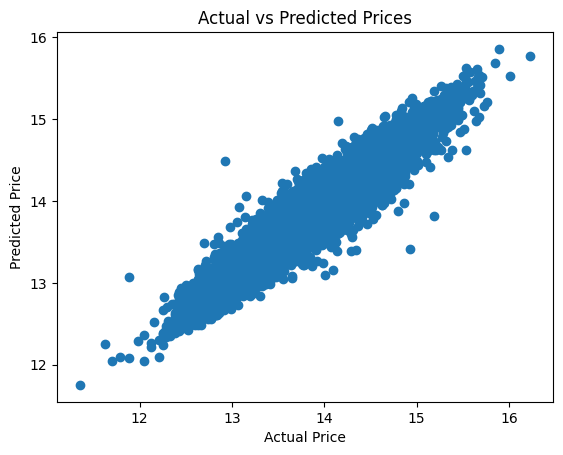

In [226]:
y_pred = final_model.predict(X_new)

plt.scatter(y, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

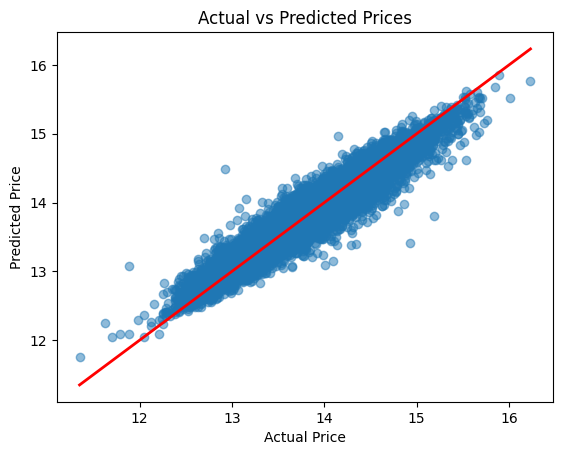

In [227]:
plt.scatter(y, y_pred, alpha=0.5)

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red',
         linewidth=2)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

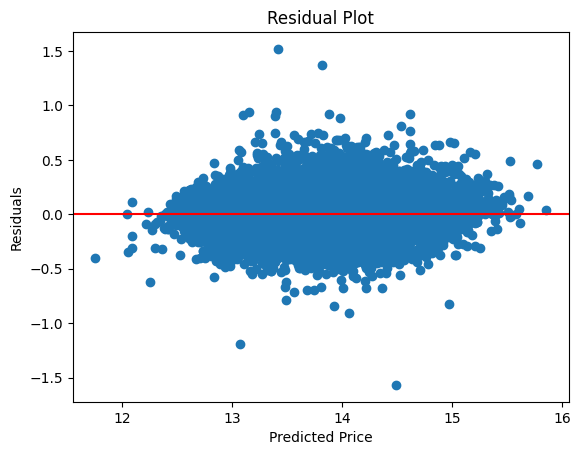

In [228]:
residuals = y - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

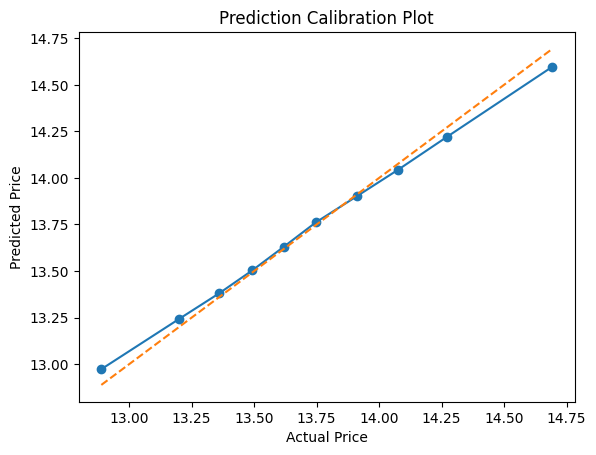

In [229]:
import pandas as pd

df_eval = pd.DataFrame({
    "Actual": y,
    "Predicted": y_pred
})

df_eval["price_bin"] = pd.qcut(df_eval["Actual"], q=10)

calibration = df_eval.groupby("price_bin").agg({
    "Actual": "mean",
    "Predicted": "mean"
}).reset_index()

import matplotlib.pyplot as plt

plt.figure()

plt.plot(calibration["Actual"], calibration["Predicted"], marker="o")
plt.plot(calibration["Actual"], calibration["Actual"], linestyle="--")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Prediction Calibration Plot")

plt.show()

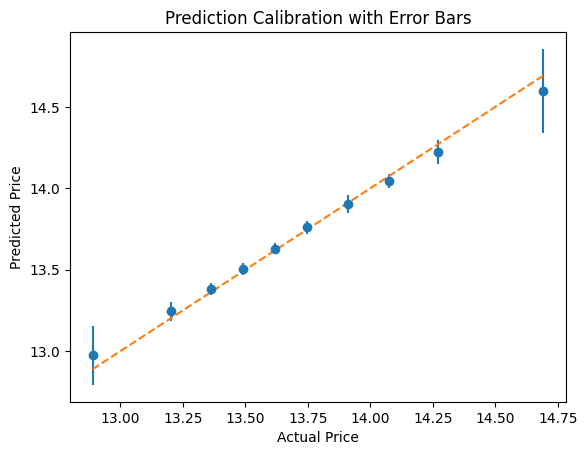

In [230]:
calibration["error"] = df_eval.groupby("price_bin")["Actual"].std().values

plt.errorbar(
    calibration["Actual"],
    calibration["Predicted"],
    yerr=calibration["error"],
    fmt="o"
)

plt.plot(calibration["Actual"], calibration["Actual"], linestyle="--")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Prediction Calibration with Error Bars")

plt.show()

In [231]:
import joblib

joblib.dump(final_model, "melbourne_house_price_model.pkl")

['melbourne_house_price_model.pkl']




##







In this project, I developed an end-to-end machine learning pipeline to predict housing prices in Melbourne using real estate transaction data. The dataset contained 34,857 records and 21 features, including property attributes, geographic variables, and transaction information. 



I began with extensive exploratory data analysis (EDA) to understand feature distributions, detect anomalies, and assess data quality. The dataset contained significant missing values across several variables such as BuildingArea, YearBuilt, Landsize, Bathroom, and Car. I performed comprehensive data preprocessing, including duplicate removal, correcting inconsistent values, handling missing data, and converting unrealistic values (e.g., zero building areas or bathrooms) into proper missing values before imputation. 

Melbourne House Price Predictio…

To enhance predictive power, I implemented feature engineering techniques. New temporal features such as Month Sold, Year Sold, and Day Sold were extracted from the transaction date, and Building Age was derived from the construction year. I also analyzed feature correlations and removed highly correlated variables such as Bedroom2 to reduce redundancy and improve model stability. 



The data preprocessing and modeling steps were integrated into a Scikit-learn pipeline, including median imputation for numerical features, most-frequent imputation for categorical features, standard scaling, and one-hot encoding. I trained and compared multiple regression models including:

Linear Regression

Ridge and ElasticNet

K-Nearest Neighbors

Random Forest

Gradient Boosting

XGBoost

LightGBM

CatBoost

Model performance was evaluated using MAE, MSE, RMSE, and R² metrics, along with 5-fold cross-validation to ensure model robustness. Among all models, CatBoost achieved the best performance, with approximately R² ≈ 0.86 and RMSE ≈ 0.19, outperforming other ensemble methods. 



To further improve model performance, I performed hyperparameter tuning using GridSearchCV and RandomizedSearchCV across advanced boosting models. The tuned CatBoost model achieved the best cross-validated performance with optimized parameters such as deeper trees and higher iterations. 



Finally, I conducted model interpretability analysis using both feature importance and permutation importance methods to identify the most influential factors affecting housing prices. Key drivers included Regionname, Distance to city center, Property Type, Number of Rooms, and Landsize, providing valuable insights into real estate pricing patterns. 